# Merged Bengali compound-character model

Trains one ResNet18 on the union of three datasets, mapped into a single label space:

- `RAS-Compound-character-dataset` (119 classes, `class_mapping.csv`)
- `ekush-dataset` (122 classes, `ekush-dataset/metaData_img.csv`)
- `MatriVasha_Dataset` (120 classes, `matrivasha_mapping_draft.csv`)

Overlapping characters (e.g. `ক্ক` appears in all three) collapse into one class, giving **256 unique classes**.
Saves `best_merged_model.pth` in the same schema as `best_bengali_vit.pth`, so `predict_word.py --model best_merged_model.pth` works unchanged.

Run `caffeinate -i` in a terminal before starting the training cell -- this is a multi-hour run and macOS will otherwise sleep and pause it.

The dataset/model classes and functions live in `train_merged.py` (imported below), not redefined in a cell -- worker processes that `DataLoader(num_workers>0)` spawns need to re-import them from a real module, which doesn't work for classes defined directly in a notebook cell (`__main__` isn't re-importable in Jupyter).

In [1]:
import time
from copy import deepcopy

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from train_merged import (
    IMG_SIZE, OLD_CHECKPOINT, BEST_CHECKPOINT, LAST_CHECKPOINT,
    build_manifest, stratified_split, CharDataset, build_transforms,
    pick_device, build_model, run_epoch,
)


In [2]:
t0 = time.time()
samples, classes = build_manifest()
NUM_CLASSES = len(classes)
print(f"{len(samples)} images, {NUM_CLASSES} classes, scanned in {time.time()-t0:.1f}s")


681309 images, 256 classes, scanned in 0.6s


In [3]:
# LIMIT_PER_CLASS = None uses everything (~681K images, ~10-13h on this Mac's GPU per 8 epochs).
# Set e.g. LIMIT_PER_CLASS = 300 for a much faster ~2-4h run if you want to iterate first.
LIMIT_PER_CLASS = None

train_samples, val_samples, test_samples = stratified_split(samples, limit_per_class=LIMIT_PER_CLASS)
print(f"Train {len(train_samples)} | Val {len(val_samples)} | Test {len(test_samples)}")


Train 545289 | Val 68010 | Test 68010


In [4]:
train_tf, eval_tf = build_transforms()

BATCH_SIZE = 32
NUM_WORKERS = 4  # safe now: CharDataset/PolarityNormalize come from train_merged.py, a real importable module

train_loader = DataLoader(CharDataset(train_samples, train_tf), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(CharDataset(val_samples, eval_tf), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
test_loader = DataLoader(CharDataset(test_samples, eval_tf), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)


In [5]:
device = pick_device()  # MPS on this Mac; override with torch.device("cpu") to force CPU (~5x slower, benchmarked)
print("Device:", device)

model = build_model(NUM_CLASSES, device)


Device: mps
Warm-started backbone from best_bengali_vit.pth


In [6]:
EPOCHS = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
RESUME = False  # set True to continue from merged_last.pth after a kernel restart

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW([
    {"params": list(model.parameters())[:-2], "lr": LR * 0.1},
    {"params": model.fc.parameters(), "lr": LR},
], weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

start_epoch = 1
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

if RESUME and LAST_CHECKPOINT.exists():
    ckpt = torch.load(LAST_CHECKPOINT, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    history = ckpt.get("history", history)
    print(f"Resumed from epoch {ckpt['epoch']}, best_val_acc={best_val_acc:.4f}")


In [7]:
for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, device, criterion, optimizer)
    va_loss, va_acc = run_epoch(model, val_loader, device, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "state_dict": deepcopy(model.state_dict()),
            "class_names": classes,
            "display_names": classes,
            "img_size": IMG_SIZE,
        }, BEST_CHECKPOINT)

    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "epoch": epoch,
        "best_val_acc": best_val_acc,
        "history": history,
    }, LAST_CHECKPOINT)

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f} | "
          f"Time: {time.time()-t0:.1f}s | Best Val: {best_val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


Epoch [01/8] Train Loss: 1.2903 Acc: 0.9143 | Val Loss: 1.0894 Acc: 0.9614 | Time: 4267.5s | Best Val: 0.9614
Epoch [02/8] Train Loss: 1.0782 Acc: 0.9588 | Val Loss: 1.0475 Acc: 0.9677 | Time: 4269.1s | Best Val: 0.9677
Epoch [03/8] Train Loss: 1.0335 Acc: 0.9668 | Val Loss: 1.0202 Acc: 0.9703 | Time: 4268.5s | Best Val: 0.9703
Epoch [04/8] Train Loss: 1.0063 Acc: 0.9716 | Val Loss: 1.0068 Acc: 0.9717 | Time: 4252.8s | Best Val: 0.9717
Epoch [05/8] Train Loss: 0.9866 Acc: 0.9755 | Val Loss: 0.9938 Acc: 0.9748 | Time: 4236.9s | Best Val: 0.9748
Epoch [06/8] Train Loss: 0.9716 Acc: 0.9785 | Val Loss: 0.9875 Acc: 0.9751 | Time: 4235.4s | Best Val: 0.9751
Epoch [07/8] Train Loss: 0.9610 Acc: 0.9807 | Val Loss: 0.9817 Acc: 0.9764 | Time: 4229.1s | Best Val: 0.9764
Epoch [08/8] Train Loss: 0.9548 Acc: 0.9822 | Val Loss: 0.9786 Acc: 0.9768 | Time: 4237.6s | Best Val: 0.9768

Best Validation Accuracy: 0.9768


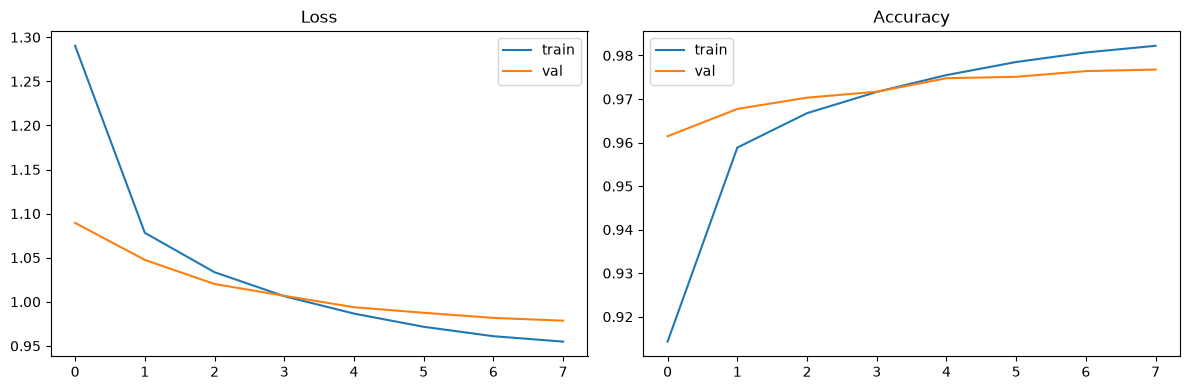

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


In [9]:
best = torch.load(BEST_CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(best["state_dict"])
test_loss, test_acc = run_epoch(model, test_loader, device, criterion)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
print(f"Saved {BEST_CHECKPOINT.name} -- use with: python predict_word.py word.png --model {BEST_CHECKPOINT.name}")


Test Accuracy: 0.9764 | Test Loss: 0.9763
Saved best_merged_model.pth -- use with: python predict_word.py word.png --model best_merged_model.pth
